# Build the Shape of a Planet Shape from Power Spectra

## Preliminaries:


1.   It is recommended to save a copy of this Jupyter Notebook to your own Google Drive first by selecting "File"->"Save a copy in Drive". This should open a copy of this notebook in a new tab.
2.   Once you've opened your own copy of this notebook, to execute a code cell below, select it and type `Shift + Enter` or place your cursor to the left of each cell until the "Run" ► button appears, and then click it.



## Installing pyshtools and its dependencies on Google Colab

Google Colab does not come with `pyshtools` and `cartopy` pre-installed. To use them, we need to follow the steps below to install them manually.

First, let's install `pyshtools` and `cartopy` on Google Colab. This may take a few minutes.

In [ ]:
!pip install pyshtools cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.9/13.9 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 33.3 MB/s eta 0:00:00


## Loading the pyshtools package

Hopefully we can now import the `pygmt` package into the Google Colab environment, along with `matplotlib.pyplot` and `numpy`

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pyshtools as pysh
from cartopy import crs as ccrs

We wish to create the spherical harmonic representation for the topography. Following Rapp (1989), for spherical harmonic degrees up to

In [ ]:
# Set maximum spherical harmonic degree, in this case l=719, following Wieczorek (2007)
lmax = 719
# Create array containing spherical harmonic degrees
degrees = np.arange(lmax+1, dtype=float)
# Set value for power law exponent, following Rapp (1989) for actual topography
beta = -2.13
# Set reference radius for the planet in kilometers (here we use the value for Earth)
r=6371
# Set value for A, following Rapp (1989) for actual topography
at = 155.4*2*np.pi*r
# Set degree 0 term to infinity to avoid the resulting singularity
degrees[0] = np.inf
# Create an array for the power spectrum using degrees
power = at*degrees**(beta)

From the form of the power spectrum that was just defined, a random realization of a set of spherical harmonic coefficients representing the topography can be generated using `.from_random()`:

In [ ]:
hlm = pysh.SHCoeffs.from_random(power, seed=12345)

The seed value for the random number generator can be changed.


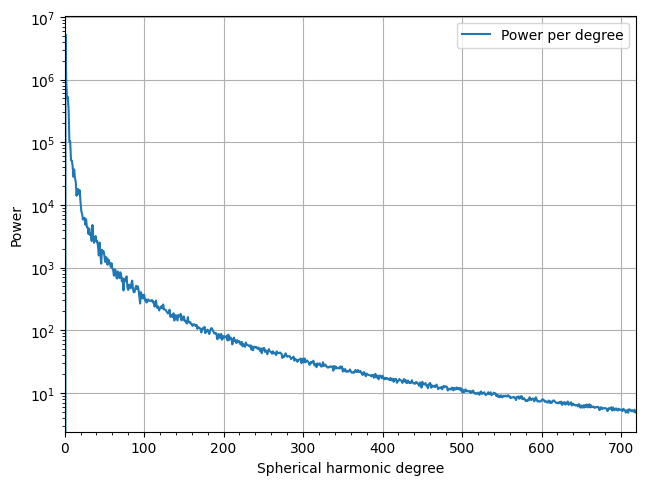

In [ ]:
fig1, ax1 = hlm.plot_spectrum(show=False)
# show=False is used to avoid a warning when plotting in inline mode

The spherical harmonic representation of the topography can now be evaluated at points within a grid using `.expand()`:

In [ ]:
grid = hlm.expand()

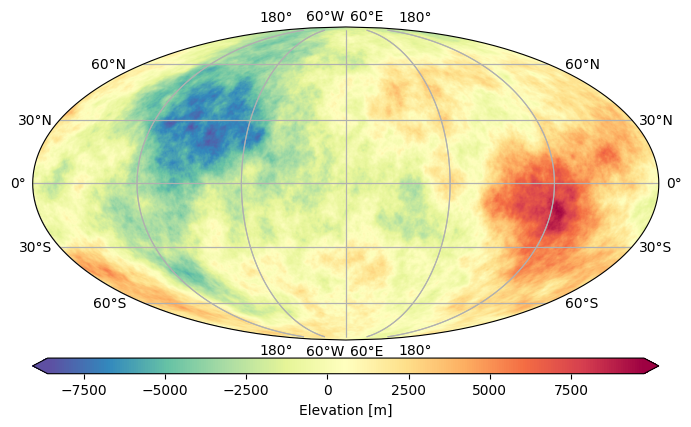

In [ ]:
fig2, ax2 = grid.plot(projection = ccrs.Mollweide(central_longitude=0.0),
                    colorbar='bottom',
                    cb_label='Elevation [m]',
                    cb_triangles='both',
                    cmap='Spectral_r',
                    grid=True,
                    tick_interval=[60,30],
                    show=False)
ax2.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)


You may choose to set a different central longitude for the projection.

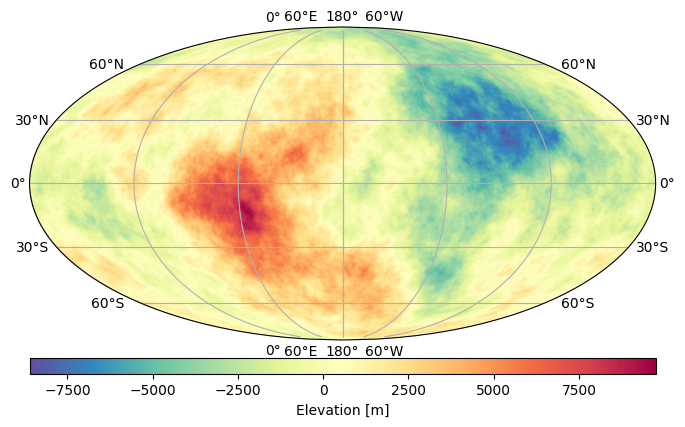

In [ ]:
clon = 180.0
fig2, ax2 = grid.plot(projection = ccrs.Mollweide(central_longitude=clon),
                    colorbar='bottom',
                    cb_label='Elevation [m]',
                    cmap='Spectral_r',
                    show=False)
ax2.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

The coordinate representation may also be rotated with the Euler angles `alpha`, `beta`, and `gamma` using `.rotate()`:

In [ ]:
rlat = 30.
rlon = 180.

alpha = 0.
beta = -(90.-rlat)
gamma = -rlon

hlm_rotated = hlm.rotate(alpha, beta,gamma, degrees=True)
grid_rotated = hlm_rotated.expand()

The results can then be plotted:

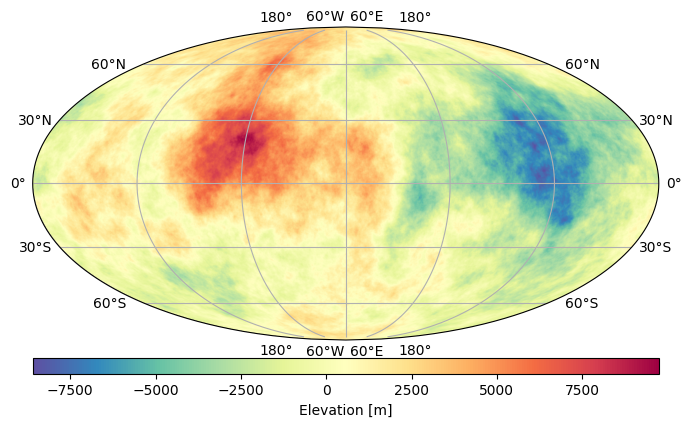

In [ ]:
clon = 0.0
fig3, ax3 = grid_rotated.plot(projection = ccrs.Mollweide(central_longitude=clon),
                    colorbar='bottom',
                    cb_label='Elevation [m]',
                    cmap='Spectral_r',
                    show=False)
ax3.gridlines(draw_labels=True, dms=True, x_inline=False, y_inline=False)

You may also try performing operations on the grid.

In [ ]:
grid2 = 2 * grid_rotated
grid2 += 100
grid2 /= 2
grid3 = grid2.copy()

## Resources
Refer to the [documentation of pyshtools](https://shtools.github.io/SHTOOLS/index.html) for more options